# FEM Solver: Lid-Driven Cavity Flow

Solves the steady incompressible **Navier-Stokes equations** on the unit square $[0,1]^2$:

$$(\mathbf{u} \cdot \nabla)\mathbf{u} - \nu \Delta \mathbf{u} + \nabla p = \mathbf{0}, \qquad \nabla \cdot \mathbf{u} = 0$$

**Boundary conditions:**
- No-slip $(\mathbf{u} = \mathbf{0})$ on the left, right, and bottom walls.
- Prescribed lid velocity $\mathbf{u} = (u_\text{lid}(x), 0)$ on the top edge ($y = 1$).

**Discretisation:** Taylor-Hood elements — quadratic velocity $(\mathcal{P}_2)$, linear pressure $(\mathcal{P}_1)$.

**Nonlinear solver:** Picard (Oseen) iteration — the convective term is linearised as $(\mathbf{u}^{(k)} \cdot \nabla)\mathbf{u}^{(k+1)}$ at each step, yielding a sequence of linear saddle-point systems solved until convergence.


In [109]:
# Install scikit-fem if not already available
# scikit-fem is a lightweight FEM library — no external solver needed
# %pip install scikit-fem


In [110]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import bmat
from scipy.sparse.linalg import spsolve

from skfem import MeshTri, Basis, ElementTriP2, ElementTriP1
from skfem.models import laplace, mass


## Parameters

Set the kinematic viscosity and the lid velocity function here.
The lid is the top edge ($y = 1$); its horizontal velocity can be any function of $x \in [0, 1]$.


In [111]:
# ── Reynolds number & derived viscosity ───────────────────────────────────────
# Re = U_ref * L / ν  with U_ref = 1 (lid speed), L = 1 (domain side)
RE        = 1000
VISCOSITY = 1.0 / RE      # kinematic viscosity ν = 1/Re = 1e-3

# ── Lid velocity: u_lid(x) gives the horizontal velocity at the top wall ───────
# U_ref = 1 → constant unit lid (standard lid-driven cavity convention)
# Change this to any callable you like, e.g.:
#   lambda x: np.sin(np.pi * x)          → smooth sinusoidal profile
#   lambda x: 16 * x**2 * (1 - x)**2    → polynomial (zero at corners)
u_lid = lambda x: 4 * x * (1 - x)

# ── Mesh resolution (number of refinements of the base unit-square mesh) ───────
MESH_REFINEMENTS = 5       # increase for higher accuracy (at higher cost)

# ── Picard (Oseen) iteration parameters ───────────────────────────────────────
PICARD_TOL      = 1e-6    # relative velocity increment stopping criterion
PICARD_MAX_ITER = 50      # maximum number of Picard iterations


## Mesh

Build a structured triangular mesh on $[0,1]^2$ and tag the four boundary edges:

| Tag | Edge        |
|-----|-------------|
| 1   | Bottom      |
| 2   | Right       |
| 3   | Top (lid)   |
| 4   | Left        |


Vertices : 4225
Elements : 8192


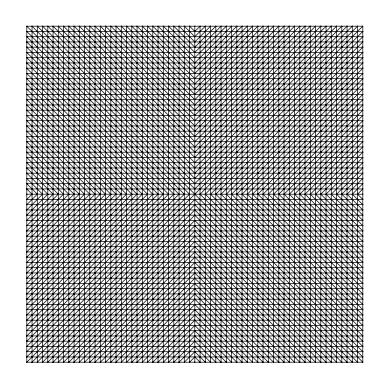

In [112]:
def make_unit_square_mesh(refinements: int) -> MeshTri:
    """
    Create a uniformly refined triangular mesh on [0,1]^2.
    Boundary facets are tagged:
        1 = bottom  (y = 0)
        2 = right   (x = 1)
        3 = top/lid (y = 1)
        4 = left    (x = 0)
    """
    mesh = MeshTri.init_sqsymmetric()           # 2×2 symmetric grid on [0,1]^2
    for _ in range(refinements):
        mesh = mesh.refined()

    mesh = mesh.with_defaults()                 # assigns default boundary tags
    return mesh


mesh = make_unit_square_mesh(MESH_REFINEMENTS)

print(f"Vertices : {mesh.p.shape[1]}")
print(f"Elements : {mesh.t.shape[1]}")
mesh.draw().show()


## FEM Assembly

### Stokes part (linear, assembled once)

The viscous and divergence blocks are assembled once and reused at every Picard step.
Using Taylor-Hood elements ($\mathcal{P}_2 / \mathcal{P}_1$) the Stokes saddle-point structure is:

$$\begin{bmatrix} A & B^\top \\ B & 0 \end{bmatrix} \begin{bmatrix} \mathbf{u} \\ p \end{bmatrix} = \begin{bmatrix} \mathbf{f} \\ \mathbf{g} \end{bmatrix}$$

where $A = \nu (K_x \oplus K_y)$ is the viscous block and $B$ is the divergence operator.

### Convection part (nonlinear, reassembled each Picard step)

The convective term is linearised via the **Picard (Oseen) iteration**:

$$(\mathbf{u}^{(k)} \cdot \nabla)\mathbf{u}^{(k+1)}$$

which contributes an additional matrix $C(\mathbf{u}^{(k)})$ to each velocity block:

$$\left[C(\mathbf{u}^{(k)})\right]_{ij} = \int_\Omega \left(\mathbf{u}^{(k)} \cdot \nabla \phi_j\right) \phi_i \, \mathrm{d}x$$

The full linearised system at iteration $k$ is:

$$\begin{bmatrix} A + C(\mathbf{u}^{(k)}) & 0 & B_x^\top \\ 0 & A + C(\mathbf{u}^{(k)}) & B_y^\top \\ B_x & B_y & 0 \end{bmatrix} \begin{bmatrix} u_x^{(k+1)} \\ u_y^{(k+1)} \\ p^{(k+1)} \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}$$


In [113]:
def assemble_stokes(mesh: MeshTri, viscosity: float):
    """
    Assemble the Stokes saddle-point system on the given mesh.

    Returns
    -------
    K_visc  : sparse block  [A   0 ]  (2×2 velocity viscous matrix, each block
                             [0   A ]   is the P2 Laplacian scaled by viscosity)
    B_div   : sparse matrix  divergence operator  (pressure DOFs × velocity DOFs)
    basis_u : Basis object for the velocity space (P2)
    basis_p : Basis object for the pressure space (P1)
    """
    # Build bases using Taylor-Hood elements
    basis_u = Basis(mesh, ElementTriP2())              # quadratic velocity
    basis_p = Basis(mesh, ElementTriP1())              # linear pressure (for standalone use)
    # Mixed-form basis: same quadrature points as basis_u, but P1 shape functions.
    # This is required by skfem — trial and test spaces must share quadrature.
    basis_p_mixed = basis_u.with_element(ElementTriP1())

    # ── Viscous block: ν ∫ ∇u · ∇v dx  (same matrix for both components) ──────
    K = viscosity * laplace.assemble(basis_u)

    # ── Divergence block: ∫ p (∂ᵢu) dx  for i = x, y ─────────────────────────
    from skfem import BilinearForm
    from skfem.helpers import grad

    @BilinearForm
    def divergence_x(u, p, w):
        """∫ p · ∂u/∂x dx"""
        return p * grad(u)[0]

    @BilinearForm
    def divergence_y(u, p, w):
        """∫ p · ∂v/∂y dx"""
        return p * grad(u)[1]

    # assemble(trial, test) → shape (test.N, trial.N) = (n_p, n_u)
    # u is trial (velocity, P2), p is test (pressure, P1)
    Bx = divergence_x.assemble(basis_u, basis_p_mixed)   # shape: (n_p, n_u)
    By = divergence_y.assemble(basis_u, basis_p_mixed)

    return K, Bx, By, basis_u, basis_p


K, Bx, By, basis_u, basis_p = assemble_stokes(mesh, VISCOSITY)

n_u = basis_u.N          # number of velocity DOFs (per component)
n_p = basis_p.N          # number of pressure DOFs
print(f"Velocity DOFs per component : {n_u}")
print(f"Pressure DOFs               : {n_p}")
print(f"Total system size           : {2 * n_u + n_p}")


Velocity DOFs per component : 16641
Pressure DOFs               : 4225
Total system size           : 37507


In [114]:
def assemble_convection(basis_u: Basis, ux_prev: np.ndarray, uy_prev: np.ndarray):
    """
    Assemble the Picard convection matrix for one velocity component:

        C[i,j] = ∫ (u_k · ∇φ_j) φ_i dx

    where u_k = (ux_prev, uy_prev) is the velocity from the previous iteration.
    The same matrix is used for both the x- and y-momentum equations because
    the Picard linearisation decouples the two components.

    Parameters
    ----------
    basis_u  : P2 velocity basis
    ux_prev  : DOF vector for the x-component of the previous velocity
    uy_prev  : DOF vector for the y-component of the previous velocity

    Returns
    -------
    C : sparse matrix of shape (n_u, n_u)
    """
    from skfem import BilinearForm
    from skfem.helpers import grad

    # Interpolate previous velocity onto quadrature points.
    # basis_u.interpolate returns a DiscreteField; passing it as a keyword arg
    # makes it available inside the form as w.<name>.
    ux_field = basis_u.interpolate(ux_prev)
    uy_field = basis_u.interpolate(uy_prev)

    @BilinearForm
    def convection(u, v, w):
        """∫ (u_k · ∇u) v dx  —  Picard linearisation"""
        return (w.ux * grad(u)[0] + w.uy * grad(u)[1]) * v

    return convection.assemble(basis_u, ux=ux_field, uy=uy_field)


## Boundary Conditions

We apply **essential (Dirichlet) boundary conditions** by identifying the DOFs on each boundary facet and prescribing their values directly:

- **No-slip** walls (bottom, right, left): $u_x = 0$, $u_y = 0$
- **Lid** (top): $u_x = u_\text{lid}(x)$, $u_y = 0$

The constrained DOFs are removed from the linear system and their prescribed values are moved to the right-hand side.


In [115]:
def get_boundary_dofs(mesh: MeshTri, basis_u: Basis, u_lid_fn, n_u: int):
    """
    Return the indices of all constrained DOFs in the full system vector
    [ux (n_u) | uy (n_u) | p (n_p)] and the corresponding prescribed values.

    Layout of the full solution vector
    ───────────────────────────────────
        indices  0 … n_u-1       →  ux component
        indices  n_u … 2n_u-1   →  uy component
        indices  2n_u …          →  pressure  (first DOF pinned to fix null-space)
    """
    # ── Velocity DOFs on each edge ─────────────────────────────────────────────
    dofs_bottom = basis_u.get_dofs(mesh.boundaries['bottom']).all()
    dofs_right  = basis_u.get_dofs(mesh.boundaries['right']).all()
    dofs_top    = basis_u.get_dofs(mesh.boundaries['top']).all()
    dofs_left   = basis_u.get_dofs(mesh.boundaries['left']).all()

    dofs_noslip = np.concatenate([dofs_bottom, dofs_right, dofs_left])  # walls
    dofs_all_boundary = np.unique(np.concatenate([dofs_noslip, dofs_top]))

    # ── Prescribed ux values (non-zero only on the lid) ───────────────────────
    ux_values = np.zeros(n_u)
    x_lid = basis_u.doflocs[0, dofs_top]      # x-coords of P2 nodes on the lid
    ux_values[dofs_top] = u_lid_fn(x_lid)

    # ── Prescribed uy values (zero everywhere on boundary) ────────────────────
    uy_values = np.zeros(n_u)

    # ── Map local velocity DOFs to the global system index ───────────────────
    constrained_ux = dofs_all_boundary              # ux block starts at 0
    constrained_uy = dofs_all_boundary + n_u        # uy block starts at n_u

    constrained_dofs = np.concatenate([constrained_ux, constrained_uy])

    # Full prescribed vector (zero by default; fill non-zero entries)
    u_prescribed = np.zeros(2 * n_u)
    u_prescribed[dofs_all_boundary]       = ux_values[dofs_all_boundary]
    u_prescribed[dofs_all_boundary + n_u] = uy_values[dofs_all_boundary]

    return constrained_dofs, u_prescribed


constrained_dofs, u_prescribed = get_boundary_dofs(mesh, basis_u, u_lid, n_u)
print(f"Constrained velocity DOFs : {len(constrained_dofs)}")


Constrained velocity DOFs : 1024


## Picard Iteration

At each iteration:
1. Interpolate the current velocity $\mathbf{u}^{(k)}$ to quadrature points.
2. Assemble the convection matrix $C(\mathbf{u}^{(k)})$.
3. Build the full saddle-point system $A + C(\mathbf{u}^{(k)})$.
4. Apply Dirichlet BCs by elimination and pin one pressure DOF.
5. Solve the reduced sparse linear system with a direct solver.
6. Compute the $H^1$ velocity increment $\|\mathbf{u}^{(k+1)} - \mathbf{u}^{(k)}\|_2 / \|\mathbf{u}^{(k+1)}\|_2$.
7. Stop when the increment falls below `PICARD_TOL`.

The Stokes solution is used as the initial guess.


In [116]:
def apply_bcs_and_solve(S, n_u, n_p, constrained_dofs, u_prescribed):
    """
    Apply Dirichlet boundary conditions (elimination method), pin the first
    pressure DOF to remove the null-space, and solve the reduced system.

    Parameters
    ----------
    S               : full assembled sparse matrix (2*n_u + n_p) × (2*n_u + n_p)
    n_u, n_p        : DOF counts for one velocity component and pressure
    constrained_dofs: indices of velocity DOFs to constrain (in the full vector)
    u_prescribed    : prescribed values for the full [ux | uy] DOF vector

    Returns
    -------
    u_full : full solution vector [ux | uy | p]
    """
    from scipy.sparse import csr_matrix

    total_dofs = 2 * n_u + n_p

    # ── RHS: lift inhomogeneous Dirichlet data ────────────────────────────────
    full_prescribed = np.zeros(total_dofs)
    full_prescribed[:2 * n_u] = u_prescribed
    rhs = -(S @ full_prescribed)

    # ── Pin first pressure DOF to fix the pressure null-space ─────────────────
    pressure_pin_dof = 2 * n_u
    all_constrained  = np.unique(np.append(constrained_dofs, pressure_pin_dof))
    free_dofs        = np.setdiff1d(np.arange(total_dofs), all_constrained)

    # ── Solve reduced system ──────────────────────────────────────────────────
    u_free = spsolve(S[free_dofs, :][:, free_dofs], rhs[free_dofs])

    u_full = full_prescribed.copy()
    u_full[free_dofs] = u_free
    return u_full


def build_system(K, C, Bx, By, n_u, n_p):
    """
    Assemble the full Navier-Stokes saddle-point matrix for a given convection C:

        ┌                        ┐
        │  K+C   0     Bx^T     │
        │  0     K+C   By^T     │
        │  Bx    By    0        │
        └                        ┘
    """
    from scipy.sparse import csr_matrix

    Z_uu = csr_matrix((n_u, n_u))
    Z_pp = csr_matrix((n_p, n_p))
    A    = K + C

    return bmat([
        [A,     Z_uu,  Bx.T],
        [Z_uu,  A,     By.T],
        [Bx,    By,    Z_pp],
    ], format='csr')


def picard_solve(K, Bx, By, basis_u, constrained_dofs, u_prescribed,
                 n_u, n_p, tol=PICARD_TOL, max_iter=PICARD_MAX_ITER):
    """
    Solve the steady Navier-Stokes equations via Picard (Oseen) iteration.

    Algorithm
    ---------
    1. Initialise with the Stokes solution (C = 0).
    2. At each step:
         a. Assemble C(u^k) from the current velocity.
         b. Build and solve the Oseen system.
         c. Compute the relative increment ‖Δu‖ / ‖u^{k+1}‖.
    3. Stop when increment < tol or max_iter is reached.

    Returns
    -------
    ux, uy, p : solution arrays at velocity (P2) and pressure (P1) DOFs
    history   : list of relative increments per iteration
    """
    from scipy.sparse import csr_matrix

    # ── Step 0: Stokes initial guess (C = 0) ─────────────────────────────────
    C0 = csr_matrix((n_u, n_u))
    S0 = build_system(K, C0, Bx, By, n_u, n_p)
    sol = apply_bcs_and_solve(S0, n_u, n_p, constrained_dofs, u_prescribed)

    ux = sol[:n_u]
    uy = sol[n_u:2 * n_u]
    p  = sol[2 * n_u:]

    print(f"  {'Iter':>4}  {'Rel. increment':>16}")
    print(f"  {'----':>4}  {'----------------':>16}")
    print(f"  {'0 (Stokes)':>10}  {'(initial guess)':>16}")

    history = []

    for k in range(1, max_iter + 1):
        ux_prev, uy_prev = ux.copy(), uy.copy()

        # ── Assemble convection with current velocity ─────────────────────────
        C = assemble_convection(basis_u, ux_prev, uy_prev)

        # ── Build and solve Oseen system ──────────────────────────────────────
        S   = build_system(K, C, Bx, By, n_u, n_p)
        sol = apply_bcs_and_solve(S, n_u, n_p, constrained_dofs, u_prescribed)

        ux = sol[:n_u]
        uy = sol[n_u:2 * n_u]
        p  = sol[2 * n_u:]

        # ── Convergence check: relative increment in velocity ─────────────────
        du   = np.sqrt(np.sum((ux - ux_prev)**2 + (uy - uy_prev)**2))
        u_norm = np.sqrt(np.sum(ux**2 + uy**2))
        rel  = du / (u_norm + 1e-300)
        history.append(rel)

        print(f"  {k:>4}  {rel:>16.3e}")

        if rel < tol:
            print(f"\n  Converged in {k} iterations (rel. increment = {rel:.2e} < {tol:.0e})")
            break
    else:
        print(f"\n  Warning: did not converge in {max_iter} iterations (last increment = {history[-1]:.2e})")

    return ux, uy, p, history


# ── Run the Picard solver ──────────────────────────────────────────────────────
print(f"Picard iterations  (Re = {RE}, tol = {PICARD_TOL})\n")
ux, uy, p, history = picard_solve(
    K, Bx, By, basis_u, constrained_dofs, u_prescribed, n_u, n_p
)

print(f"\nMax |ux| = {np.abs(ux).max():.4f}")
print(f"Max |uy| = {np.abs(uy).max():.4f}")
print(f"Pressure range: [{p.min():.4f}, {p.max():.4f}]")


Picard iterations  (Re = 1000, tol = 1e-06)

  Iter    Rel. increment
  ----  ----------------
  0 (Stokes)   (initial guess)
     1         6.186e-01
     2         2.199e-01
     3         9.268e-02
     4         1.994e-02
     5         9.249e-03
     6         3.609e-03
     7         2.499e-03
     8         1.353e-03
     9         7.796e-04
    10         4.332e-04
    11         2.530e-04
    12         1.498e-04
    13         8.925e-05
    14         5.268e-05
    15         3.089e-05
    16         1.807e-05
    17         1.059e-05
    18         6.222e-06
    19         3.658e-06
    20         2.149e-06
    21         1.262e-06
    22         7.409e-07

  Converged in 22 iterations (rel. increment = 7.41e-07 < 1e-06)

Max |ux| = 1.0000
Max |uy| = 0.5106
Pressure range: [-0.1970, 0.0808]


## Results


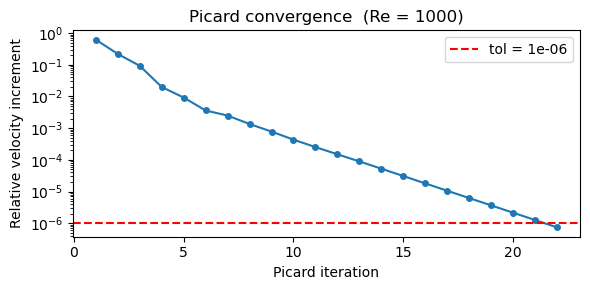

In [117]:
# ── Picard convergence history ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(range(1, len(history) + 1), history, 'o-', markersize=4)
ax.axhline(PICARD_TOL, color='r', linestyle='--', label=f'tol = {PICARD_TOL:.0e}')
ax.set_xlabel('Picard iteration')
ax.set_ylabel('Relative velocity increment')
ax.set_title(f'Picard convergence  (Re = {RE})')
ax.legend()
plt.tight_layout()
plt.show()


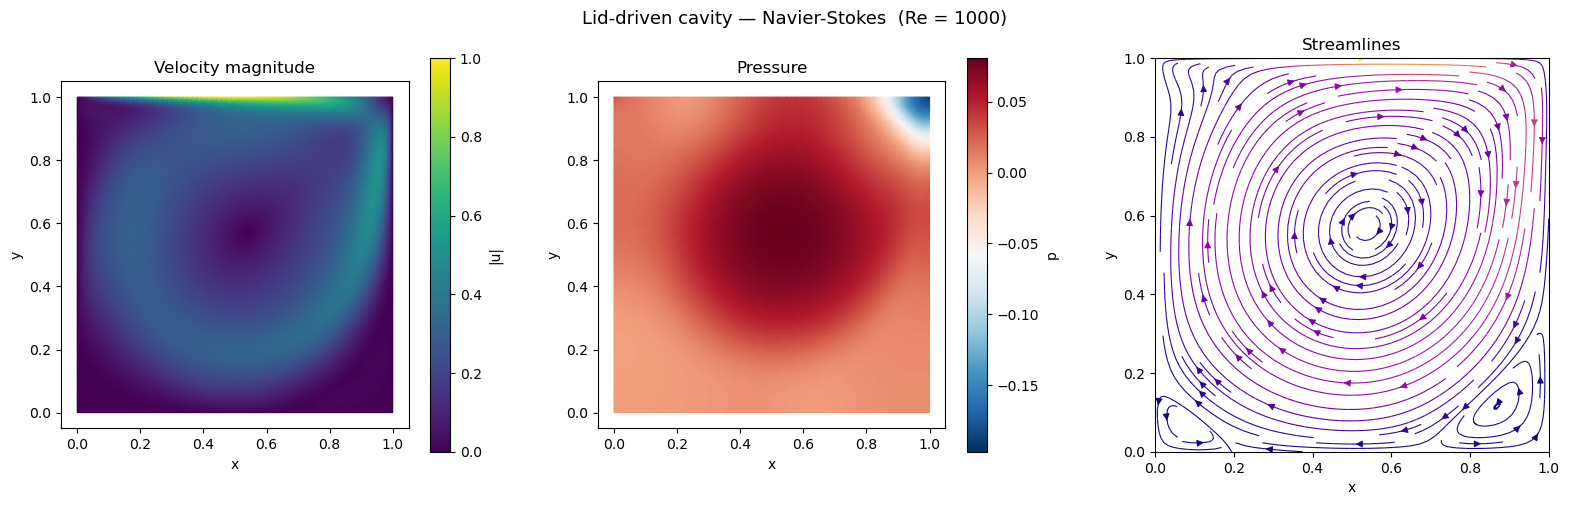

In [118]:
def plot_results(mesh, basis_u, basis_p, ux, uy, p):
    """
    Plot the velocity magnitude, pressure field, and streamlines.
    The P2 velocity values are interpolated onto a regular grid for streamlines.
    """
    # ── Node coordinates for P2 (velocity) and P1 (pressure) ─────────────────
    x_u, y_u = basis_u.doflocs[0], basis_u.doflocs[1]
    x_p, y_p = basis_p.doflocs[0], basis_p.doflocs[1]

    speed = np.sqrt(ux**2 + uy**2)

    # ── Interpolate velocity onto a uniform Cartesian grid (for streamlines) ──
    from scipy.interpolate import LinearNDInterpolator

    grid_res = 80
    xi = np.linspace(0, 1, grid_res)
    yi = np.linspace(0, 1, grid_res)
    Xi, Yi = np.meshgrid(xi, yi)

    interp_ux = LinearNDInterpolator(list(zip(x_u, y_u)), ux)
    interp_uy = LinearNDInterpolator(list(zip(x_u, y_u)), uy)
    Ux = interp_ux(Xi, Yi)
    Uy = interp_uy(Xi, Yi)

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # — Velocity magnitude —
    sc1 = axes[0].tripcolor(x_u, y_u, speed, cmap='viridis', shading='gouraud')
    plt.colorbar(sc1, ax=axes[0], label='|u|')
    axes[0].set_title('Velocity magnitude')
    axes[0].set_aspect('equal')

    # — Pressure field —
    sc2 = axes[1].tripcolor(x_p, y_p, p, cmap='RdBu_r', shading='gouraud')
    plt.colorbar(sc2, ax=axes[1], label='p')
    axes[1].set_title('Pressure')
    axes[1].set_aspect('equal')

    # — Streamlines —
    axes[2].streamplot(Xi, Yi, Ux, Uy, color=np.sqrt(Ux**2 + Uy**2),
                       cmap='plasma', density=1.5, linewidth=0.8)
    axes[2].set_title('Streamlines')
    axes[2].set_aspect('equal')
    axes[2].set_xlim(0, 1)
    axes[2].set_ylim(0, 1)

    for ax in axes:
        ax.set_xlabel('x')
        ax.set_ylabel('y')

    plt.suptitle(f'Lid-driven cavity — Navier-Stokes  (Re = {RE})', fontsize=13)
    plt.tight_layout()
    plt.show()


plot_results(mesh, basis_u, basis_p, ux, uy, p)


Sampled points     : 10000
Valid (non-NaN)    : 10000
Max |u| at samples : 0.9760
Pressure range     : [-0.1872, 0.0808]


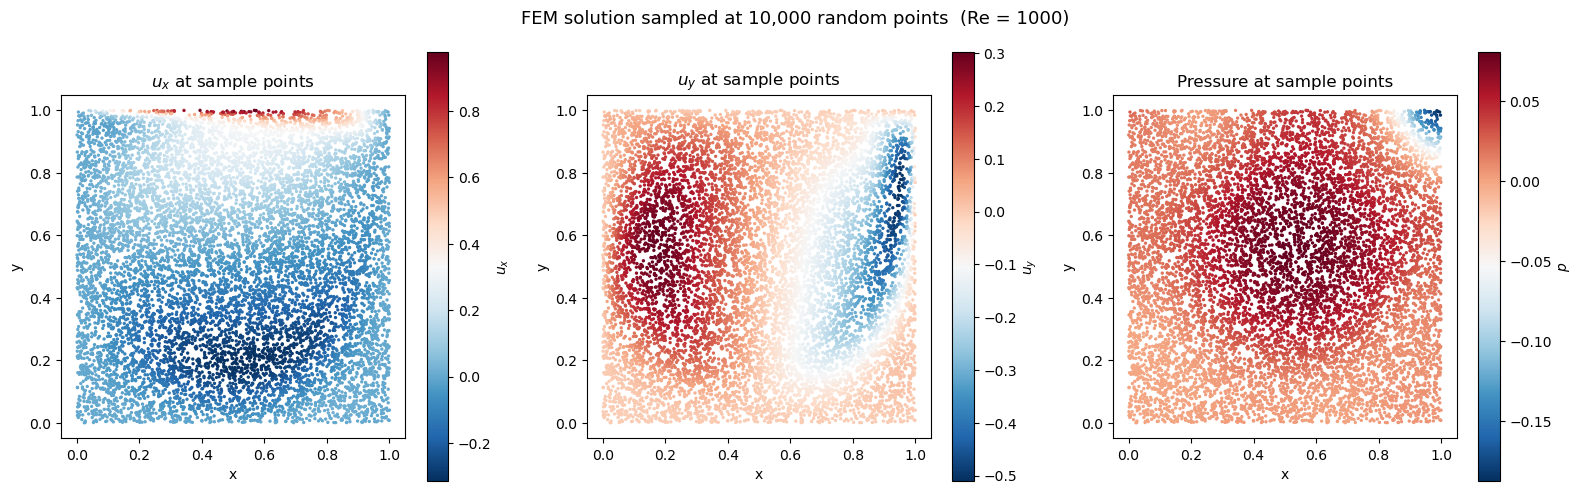

In [119]:
from scipy.interpolate import LinearNDInterpolator

# ── Sample ~10 000 random points inside [0,1]^2 ───────────────────────────────
rng        = np.random.default_rng(42)
n_samples  = 10_000
pts        = rng.uniform(0.0, 1.0, size=(n_samples, 2))   # shape (N, 2)

# ── Coordinates of the FEM DOFs ───────────────────────────────────────────────
x_u, y_u = basis_u.doflocs[0], basis_u.doflocs[1]   # P2 velocity nodes
x_p, y_p = basis_p.doflocs[0], basis_p.doflocs[1]   # P1 pressure nodes

# ── Build interpolators from the FEM DOF values ───────────────────────────────
interp_ux = LinearNDInterpolator(np.column_stack([x_u, y_u]), ux)
interp_uy = LinearNDInterpolator(np.column_stack([x_u, y_u]), uy)
interp_p  = LinearNDInterpolator(np.column_stack([x_p, y_p]), p)

# ── Evaluate at the sample points ─────────────────────────────────────────────
ux_pts    = interp_ux(pts)          # shape (N,)
uy_pts    = interp_uy(pts)          # shape (N,)
p_pts     = interp_p(pts)           # shape (N,)
speed_pts = np.sqrt(ux_pts**2 + uy_pts**2)

# Any point that fell outside the convex hull of the triangulation gets NaN;
# mask those out (should be negligible for the unit square).
valid = np.isfinite(ux_pts) & np.isfinite(uy_pts) & np.isfinite(p_pts)
print(f"Sampled points     : {n_samples}")
print(f"Valid (non-NaN)    : {valid.sum()}")
print(f"Max |u| at samples : {speed_pts[valid].max():.4f}")
print(f"Pressure range     : [{p_pts[valid].min():.4f}, {p_pts[valid].max():.4f}]")

# ── Scatter plot coloured by speed ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sc0 = axes[0].scatter(pts[valid, 0], pts[valid, 1],
                      c=ux_pts[valid], cmap='RdBu_r', s=2, rasterized=True)
plt.colorbar(sc0, ax=axes[0], label='$u_x$')
axes[0].set_title('$u_x$ at sample points')

sc1 = axes[1].scatter(pts[valid, 0], pts[valid, 1],
                      c=uy_pts[valid], cmap='RdBu_r', s=2, rasterized=True)
plt.colorbar(sc1, ax=axes[1], label='$u_y$')
axes[1].set_title('$u_y$ at sample points')

sc2 = axes[2].scatter(pts[valid, 0], pts[valid, 1],
                      c=p_pts[valid],  cmap='RdBu_r', s=2, rasterized=True)
plt.colorbar(sc2, ax=axes[2], label='$p$')
axes[2].set_title('Pressure at sample points')

for ax in axes:
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle(f'FEM solution sampled at {n_samples:,} random points  (Re = {RE})', fontsize=13)
plt.tight_layout()
plt.show()


In [120]:
import h5py, os

save_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "cavity_solution.h5")

with h5py.File(save_path, "w") as f:
    # ── Metadata ──────────────────────────────────────────────────────────────
    f.attrs["RE"]             = RE
    f.attrs["VISCOSITY"]      = VISCOSITY
    f.attrs["MESH_REFINEMENTS"] = MESH_REFINEMENTS
    f.attrs["n_samples"]      = int(valid.sum())

    # ── Sample point coordinates (valid only) ─────────────────────────────────
    f.create_dataset("x",  data=pts[valid, 0], compression="gzip")
    f.create_dataset("y",  data=pts[valid, 1], compression="gzip")

    # ── Field values at sample points ─────────────────────────────────────────
    f.create_dataset("ux", data=ux_pts[valid], compression="gzip")
    f.create_dataset("uy", data=uy_pts[valid], compression="gzip")
    f.create_dataset("p",  data=p_pts[valid],  compression="gzip")

print(f"Saved {valid.sum():,} sample points to: {save_path}")
print(f"Datasets : x, y, ux, uy, p  |  shape: ({valid.sum()},)")


Saved 10,000 sample points to: /home/berva/Projects2/Projects/PINNs/Introduction/notebooks/cavity_flow/cavity_solution.h5
Datasets : x, y, ux, uy, p  |  shape: (10000,)
